In [1]:
from IPython.core.display import HTML

HTML("""
<style>

h1 { color: blue !important; }
h2 { color: green !important; }
</style>
""")

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

# Step 1: Read and explore the data


In [2]:
#Predict class of car
#unacc: Unacceptable
#acc: Acceptable
#good: Good
#vgood: very Good

In [3]:
data = pd.read_csv("cars_data.csv")

In [4]:
data.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [6]:
data.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [7]:
data['class'].value_counts()

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64

# Step 2: Identify important features

In [8]:
from scipy.stats import chi2_contingency
  
# defining the table
for column in data.columns:
    if(column!='class'):
        table = pd.crosstab(data[column], data['class'])
        print(table)
        stat, p, dof, expected = chi2_contingency(table)
        print("Chi-square test for feature: ", column
             )
        print("p-value : ", p)
        print("")
        print("")

class   acc  good  unacc  vgood
buying                         
high    108     0    324      0
low      89    46    258     39
med     115    23    268     26
vhigh    72     0    360      0
Chi-square test for feature:  buying
p-value :  5.9280625992133936e-36


class  acc  good  unacc  vgood
maint                         
high   105     0    314     13
low     92    46    268     26
med    115    23    268     26
vhigh   72     0    360      0
Chi-square test for feature:  maint
p-value :  2.5476519845077733e-26


class  acc  good  unacc  vgood
doors                         
2       81    15    326     10
3       99    18    300     15
4      102    18    292     20
5more  102    18    292     20
Chi-square test for feature:  doors
p-value :  0.32024215990030563


class    acc  good  unacc  vgood
persons                         
2          0     0    576      0
4        198    36    312     30
more     186    33    322     35
Chi-square test for feature:  persons
p-value :  4.039968

In [9]:
data['class'].value_counts()

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64

# Step 3: Train Test split the data

In [10]:
def train_test_split_and_features(data):
    y = data["class"]
    x = data.drop('class',axis=1)
    x = pd.get_dummies(x) 
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test,features


In [11]:
x_train, x_test, y_train, y_test,features = train_test_split_and_features(data)

   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0            0           0           0             1           0          0   
1            0           0           0             1           0          0   
2            0           0           0             1           0          0   
3            0           0           0             1           0          0   
4            0           0           0             1           0          0   

   maint_med  maint_vhigh  doors_2  doors_3  ...  doors_5more  persons_2  \
0          0            1        1        0  ...            0          1   
1          0            1        1        0  ...            0          1   
2          0            1        1        0  ...            0          1   
3          0            1        1        0  ...            0          1   
4          0            1        1        0  ...            0          1   

   persons_4  persons_more  lug_boot_big  lug_boot_med  lug_boot_sma

In [12]:
x_train

,buying_high,buying_low,buying_med,buying_vhigh,maint_high,maint_low,maint_med,maint_vhigh,doors_2,doors_3,...,doors_5more,persons_2,persons_4,persons_more,lug_boot_big,lug_boot_med,lug_boot_small,safety_high,safety_low,safety_med
1649,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
1465,0,1,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
361,0,0,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,1,0,0,1
315,0,0,0,1,0,0,1,0,0,0,...,1,0,0,1,0,0,1,0,1,0
1372,0,1,0,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,1,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,1
1216,0,0,1,0,0,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,1
1653,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
559,1,0,0,0,1,0,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1


In [13]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None)
 |  
 |  A random forest classifier.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  The sub-sample size is controlled with the `max_samples` parameter if
 |  `bootstrap=True` (default), otherwise the whole dataset is used to build
 |  each tree.
 |  
 |  Read more in the :ref:`User Guide <forest>`.
 |  
 |  Parameters
 |  ----------


# Step 3: Fit and evaluate model

In [ ]:
# max_depth= 5 ,
# min_samples_split= 0.01,  90 data points ( 90 rows)- split wont be
#max_features=0.8, - feature bagging - 16 out of 21 features would be used  to find split
#max_samples=0.8  - data bagging - use randomly sampled 80% rows from training data in every decision tree
#n_estimators - number of decision trees - by default 100

In [14]:
# n_estimators = 100 by default  ( you can try with different values)
# bootstrap ( data row bagging) is True by default
# max_samples = 1

def fit_and_evaluate_model(x_train, x_test, y_train, y_test,max_depth=5,min_samples_split=0.01,max_features=0.8,max_samples=0.8):
    random_forest =  RandomForestClassifier(random_state=0,\
                                            max_depth=max_depth,\
                                            min_samples_split=min_samples_split,\
                                            max_features=max_features,
                                            max_samples=max_samples)

    model = random_forest.fit(x_train, y_train)
    random_forest_predict = random_forest.predict(x_test)
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)
    print("confussion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model


In [15]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

confussion matrix
[[ 79   0   0   0]
 [ 15   0   0   2]
 [ 18   0 222   0]
 [  7   0   0   3]]


Accuracy of Random Forest: 87.86127167630057 

              precision    recall  f1-score   support

         acc       0.66      1.00      0.80        79
        good       0.00      0.00      0.00        17
       unacc       1.00      0.93      0.96       240
       vgood       0.60      0.30      0.40        10

    accuracy                           0.88       346
   macro avg       0.57      0.56      0.54       346
weighted avg       0.86      0.88      0.86       346



# Step 4: Try different parameters to identify best ones

In [16]:
param_grid = [
  {'max_depth': [3,5,7,10], 'min_samples_split': [0.01,0.03, 0.07, 0.1], 
'max_features': [0.7,0.8,0.9,1.0],
'max_samples': [0.7,0.8,0.9,1.0]}]

In [17]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
search = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, verbose=5)
search.fit(x_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.823 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.812 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.801 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.859 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.837 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.830 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.776 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.808 total time=   0.1s


[CV 2/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.07;, score=0.791 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.07;, score=0.804 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.07;, score=0.855 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.07;, score=0.841 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.1;, score=0.819 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.1;, score=0.791 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.1;, score=0.804 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_samples_split=0.1;, score=0.837 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=1.0, min_sam

[CV 4/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.01;, score=0.822 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.01;, score=0.837 total time=   0.0s
[CV 1/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.03;, score=0.819 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.03;, score=0.776 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.03;, score=0.786 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.03;, score=0.848 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.03;, score=0.841 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=0.8, max_samples=1.0, min_samples_split=0.07;, score=0.823 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.8, max_samples=1.0, min

[CV 1/5] END max_depth=3, max_features=0.9, max_samples=0.9, min_samples_split=0.1;, score=0.830 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.9, max_samples=0.9, min_samples_split=0.1;, score=0.776 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.9, max_samples=0.9, min_samples_split=0.1;, score=0.797 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.9, max_samples=0.9, min_samples_split=0.1;, score=0.837 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=0.9, max_samples=0.9, min_samples_split=0.1;, score=0.837 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=0.9, max_samples=1.0, min_samples_split=0.01;, score=0.816 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=0.9, max_samples=1.0, min_samples_split=0.01;, score=0.776 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=0.9, max_samples=1.0, min_samples_split=0.01;, score=0.797 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=0.9, max_samples=1.0, min_samp

[CV 3/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.03;, score=0.797 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.03;, score=0.812 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.03;, score=0.837 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.07;, score=0.809 total time=   0.1s
[CV 2/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.07;, score=0.776 total time=   0.1s
[CV 3/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.07;, score=0.797 total time=   0.1s
[CV 4/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.07;, score=0.833 total time=   0.1s
[CV 5/5] END max_depth=3, max_features=1.0, max_samples=0.9, min_samples_split=0.07;, score=0.837 total time=   0.1s
[CV 1/5] END max_depth=3, max_features=1.0, max_samples=0.9, min

...

[CV 5/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.01;, score=0.964 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.03;, score=0.931 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.03;, score=0.903 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.03;, score=0.920 total time=   0.1s
[CV 4/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.03;, score=0.964 total time=   0.1s
[CV 5/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.03;, score=0.928 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.07;, score=0.852 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.7, max_samples=0.9, min_samples_split=0.07;, score=0.827 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.7, max_samples

[CV 5/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.07;, score=0.859 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.1;, score=0.834 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.1;, score=0.816 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.1;, score=0.837 total time=   0.1s
[CV 4/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.1;, score=0.855 total time=   0.1s
[CV 5/5] END max_depth=10, max_features=0.8, max_samples=0.8, min_samples_split=0.1;, score=0.859 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.8, max_samples=0.9, min_samples_split=0.01;, score=0.949 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.8, max_samples=0.9, min_samples_split=0.01;, score=0.960 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.8, max_samples=0.9,

[CV 5/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.01;, score=0.960 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.03;, score=0.913 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.03;, score=0.906 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.03;, score=0.920 total time=   0.1s
[CV 4/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.03;, score=0.957 total time=   0.1s
[CV 5/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.03;, score=0.917 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.07;, score=0.834 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=0.9, max_samples=0.8, min_samples_split=0.07;, score=0.787 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=0.9, max_samples

[CV 5/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.07;, score=0.859 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.1;, score=0.827 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.1;, score=0.801 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.1;, score=0.844 total time=   0.1s
[CV 4/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.1;, score=0.866 total time=   0.1s
[CV 5/5] END max_depth=10, max_features=1.0, max_samples=0.7, min_samples_split=0.1;, score=0.855 total time=   0.1s
[CV 1/5] END max_depth=10, max_features=1.0, max_samples=0.8, min_samples_split=0.01;, score=0.949 total time=   0.1s
[CV 2/5] END max_depth=10, max_features=1.0, max_samples=0.8, min_samples_split=0.01;, score=0.960 total time=   0.1s
[CV 3/5] END max_depth=10, max_features=1.0, max_samples=0.8,

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [3, 5, 7, 10],
                          'max_features': [0.7, 0.8, 0.9, 1.0],
                          'max_samples': [0.7, 0.8, 0.9, 1.0],
                          'min_samples_split': [0.01, 0.03, 0.07, 0.1]}],
             verbose=5)

In [18]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True,ascending= False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
204,0.162530,0.007139,0.015627,0.000011,10,0.7,1.0,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.956679,0.956679,0.952899,0.996377,0.956522,0.963831,0.016337,1
248,0.175663,0.003176,0.012495,0.006247,10,1.0,0.9,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.956679,0.960289,0.949275,0.996377,0.956522,0.963828,0.016663,2
200,0.158980,0.002482,0.015637,0.000019,10,0.7,0.9,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.949458,0.956679,0.949275,0.996377,0.963768,0.963111,0.017471,3
208,0.160479,0.003888,0.012499,0.006249,10,0.8,0.7,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.953069,0.956679,0.949275,0.996377,0.960145,0.963109,0.017024,4
228,0.166007,0.007694,0.012501,0.006251,10,0.9,0.8,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.949458,0.960289,0.949275,0.996377,0.960145,0.963109,0.017327,4
244,0.175439,0.003156,0.009366,0.007647,10,1.0,0.8,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.949458,0.960289,0.949275,0.996377,0.960145,0.963109,0.017327,4
220,0.173076,0.006551,0.009375,0.007655,10,0.8,1.0,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.949458,0.960289,0.949275,0.996377,0.956522,0.962384,0.017511,7
216,0.171898,0.008719,0.003121,0.006242,10,0.8,0.9,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.949458,0.960289,0.949275,0.996377,0.956522,0.962384,0.017511,7
236,0.172310,0.006851,0.009372,0.007652,10,0.9,1.0,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.949458,0.960289,0.949275,0.996377,0.956522,0.962384,0.017511,7
192,0.163175,0.007444,0.012495,0.006248,10,0.7,0.7,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.945848,0.953069,0.952899,0.996377,0.960145,0.961667,0.017934,10


In [19]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_save.csv", index =False)

In [20]:
search.best_params_

{'max_depth': 10,
 'max_features': 0.7,
 'max_samples': 1.0,
 'min_samples_split': 0.01}

# Step 5: Evaluate the model with best parameters

In [25]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=10,min_samples_split=0.01,\
                               max_features=0.7,max_samples= 1.0)

confussion matrix
[[ 74   4   0   1]
 [  0  13   0   4]
 [  8   0 232   0]
 [  0   0   0  10]]


Accuracy of Random Forest: 95.08670520231213 

              precision    recall  f1-score   support

         acc       0.90      0.94      0.92        79
        good       0.76      0.76      0.76        17
       unacc       1.00      0.97      0.98       240
       vgood       0.67      1.00      0.80        10

    accuracy                           0.95       346
   macro avg       0.83      0.92      0.87       346
weighted avg       0.96      0.95      0.95       346



In [26]:
importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance','feature']
importances.sort_values(by = 'importance', ascending= True,inplace=True)

<BarContainer object of 21 artists>

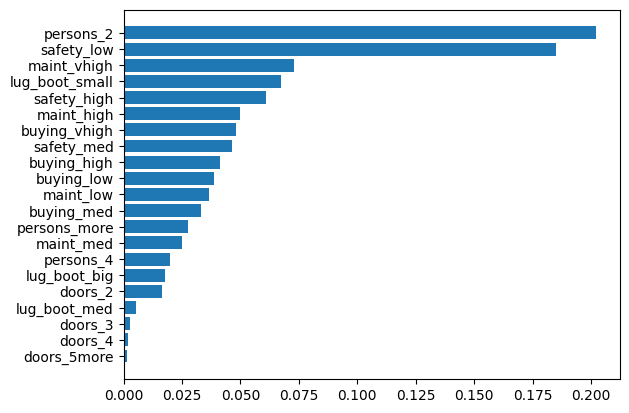

In [27]:
import matplotlib.pyplot as plt
plt.barh(importances.feature, importances.importance)

In [ ]:
# 100
# 45 features non zero feature importance score
# rebuild the ML model using only those 45 

# 100 features - 